In [25]:
import numpy as np
import matplotlib.pyplot as plt
from gaiamock import gaiamock_var  as gm
from gaiamock import gaiamock_mod  as gmo
from gaiamock import variability_tool as vt
import pandas as pd
path_to_data="/Users/giulianoiorio/Dropbox/Work_Project/RRLgaiamock/paper/data/healpix_scans/healpix_scans"
gm.set_healpyx_table_path(path_to_data)
gmo.set_healpyx_table_path(path_to_data)

RUWE 1.2021975794234976
RUWE 1.6058552684630918


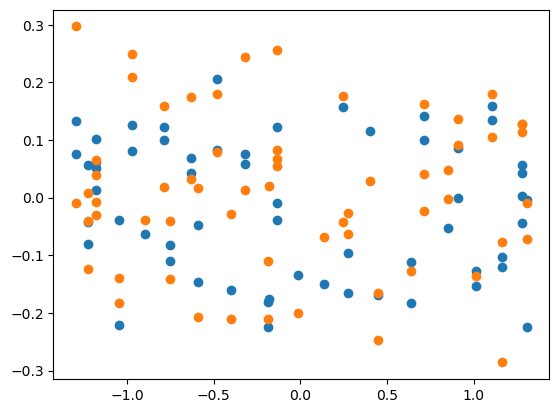

In [2]:
ra=230
dec=35
pmra=0
pmdec=0
parallax=0.2
phot_g_mean_mag=14

#JDB_TCB = t_gaia + 2455197.5

t,psi,plx, Lambda, error = gm.predict_astrometry_single_source(ra=ra,dec=dec,
                                    pmra=pmra,pmdec=pmdec,
                                    parallax=parallax,
                                    data_release="dr3",
                                    phot_g_mean_mag=phot_g_mean_mag
                                   )
print("RUWE",gm.check_ruwe(t_ast_yr=t, psi=psi, plx_factor=plx, ast_obs=Lambda, ast_err=error,binned=False)[0])
plt.scatter(t,Lambda)

varmodel=vt.SimpleSinusoidal(amp=0.3,period=0.27,fchrom=0.3,relative_norm=False)
t,psi,plx, Lambda, error = gm.predict_astrometry_single_source(ra=ra,dec=dec,
                                    pmra=pmra,pmdec=pmdec,
                                    parallax=parallax,
                                    data_release="dr3",
                                    phot_g_mean_mag=phot_g_mean_mag,
                                    variability_tool=varmodel
                                   )
print("RUWE",gm.check_ruwe(t_ast_yr=t, psi=psi, plx_factor=plx, ast_obs=Lambda, ast_err=error,binned=False)[0])
plt.scatter(t,Lambda)

In [3]:
#Realistic RRL from Gaia

class LCtemplate:
    def __init__(self, zp_mag, A, Phi, narm, reference_time,period,
                obs_average):
        
        self.REF_TIME_SCALE = 2455197.5 #The reference time in the Gaia archive are reported as BJD in TCB - 2455197.5, but here we assume that the time is always in tBJD in TCB
        self.zp_mag = zp_mag
        self.narm = narm
        self.A    = A[:narm]
        self.Phi  = Phi[:narm]
        self.reference_time = reference_time
        self.period = period
        self.iarm = np.arange(1,narm+1)
        self.obs_average   = obs_average

    def lc(self,x,folded=False):

        if folded:
            phase=x
        else:
            phase=(x-self.REF_TIME_SCALE-self.reference_time)/self.period 
        
        return self.zp_mag + np.sum([ self.A[i]*np.cos(2*np.pi*self.iarm[i]*phase+self.Phi[i]) for i in range(self.narm) ],axis=0)
        

    def lc_der(self,x,folded=False):

        if folded:
            phase=x
            dmod_dx = 2*np.pi*self.iarm
        else:
            phase=(x-self.REF_TIME_SCALE-self.reference_time)/self.period 
            dmod_dx = 2*np.pi*self.iarm/self.period
            
        return np.sum([ -self.A[i]*dmod_dx[i]*np.sin(2*np.pi*self.iarm[i]*phase+self.Phi[i]) for i in range(self.narm) ],axis=0)
    

class RRLVariable(vt.VariabilityTool):


    def __init__(self,gaiadf,fchrom,relative_norm=True):
        super().__init__(fchrom=fchrom,relative_norm=relative_norm)

        self.LCtemplate_bp = self.reconstruct_lc(gaiadf,band="bp")
        self.LCtemplate_rp = self.reconstruct_lc(gaiadf,band="rp")
        self.LCtemplate_g = self.reconstruct_lc(gaiadf,band="g")
        

    def __call__(self, time):
        #Transform 
        average_color=self.LCtemplate_bp.obs_average - self.LCtemplate_rp.obs_average
        return (self.LCtemplate_bp.lc(time)  - self.LCtemplate_rp.lc(time))-average_color

    def g_lcurve(self,time):
        return self.LCtemplate_g.lc(time)
    
    @staticmethod
    def reconstruct_lc(df,band="g"):
        """
        In Gaia SOS the RRL light curve are fitted with a Fourier series as
        G(t) = zp + Sum A_i cos(2pi i nu_max (t-tref) + Phi_i)
        where zp is the zero poing magnitude, A_i and Phi_i are the amplitude 
        of the armonics, with nu_max the frequencey of the fundamental one with nu_max=1/Period
        """
        
        zp_mag = df[f"zp_mag_{band}"] #zero point for the Fourier curve decomposition
        numax=df["fund_freq1"] #numax (1/Period)
        narm=df[f"num_harmonics_for_p1_{band}"]
        reference_time = df[f"reference_time_{band}"] #Reference time for the fourier curve decomposition
        Ai=df[f"fund_freq1_harmonic_ampl_{band}"][:narm]
        Phii=df[f"fund_freq1_harmonic_phase_{band}"][:narm]
        iarm = np.arange(1,narm+1)
        obs_average = df[f"int_average_{band}"]
    
        return LCtemplate(zp_mag=zp_mag, A=Ai, Phi=Phii, narm=narm, 
                          reference_time=reference_time, period=1/numax,
                         obs_average=obs_average)

datadf=pd.read_parquet("/Users/giulianoiorio/Dropbox/Work_Project/RRLgaiamock/paper/data/RRL/RL_G3_kine_reduced_wIB21_extramet_cleaned_highmet_wharmonics.parquet")

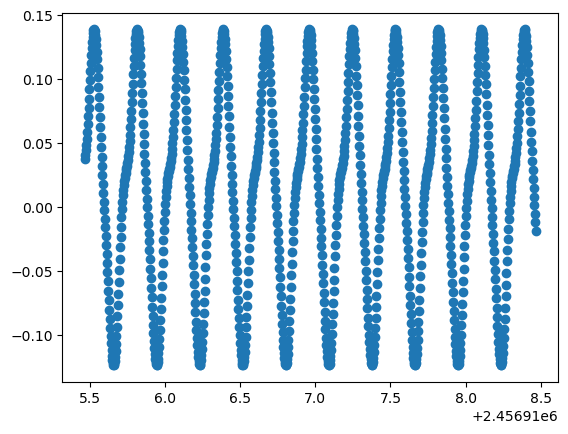

In [113]:
fr=RRLVariable(datadf.iloc[12],fchrom=0.2)

xx=np.linspace(0,3,int(1000))+fr.LCtemplate_g.reference_time+2455197.5 
#fr.LCtemplate_bp.reference_time
fr(xx)
plt.scatter(xx,fr(xx))
#plt.plot(xx,fr.g_lcurve(xx))
#plt.axhline(fr.LCtemplate_bp.obs_average-fr.LCtemplate_rp.obs_average)
#plt.scatter(xx,fr.LCtemplate_bp.lc(xx))
#plt.axhline(fr.LCtemplate_bp.obs_average)
#plt.scatter(xx,fr.LCtemplate_rp.lc(xx))
#plt.axhline(fr.LCtemplate_rp.obs_average)

RUWE 1.2706375569766004
RUWE 1.167198675003273


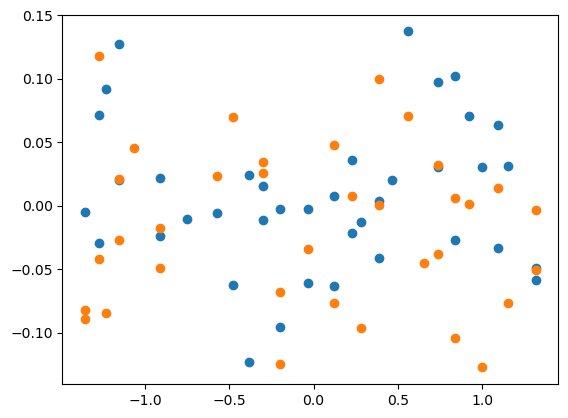

In [24]:
ra=230
dec=60
pmra=0
pmdec=0
parallax=0.05
phot_g_mean_mag=12

t,psi,plx, Lambda, error = gm.predict_astrometry_single_source(ra=ra,dec=dec,
                                    pmra=pmra,pmdec=pmdec,
                                    parallax=parallax,
                                    data_release="dr3",
                                    phot_g_mean_mag=phot_g_mean_mag,
                                   )
print("RUWE",gmo.check_ruwe(t_ast_yr=t, psi=psi, plx_factor=plx, ast_obs=Lambda, ast_err=error,binned=False)[0])
plt.scatter(t,Lambda)


varmodel=RRLVariable(datadf.iloc[59],fchrom=0.3,relative_norm=False)
t,psi,plx, Lambda, error = gm.predict_astrometry_single_source(ra=ra,dec=dec,
                                    pmra=pmra,pmdec=pmdec,
                                    parallax=parallax,
                                    data_release="dr3",
                                    phot_g_mean_mag=phot_g_mean_mag,
                                    variability_tool=varmodel
                                   )
print("RUWE",gm.check_ruwe(t_ast_yr=t, psi=psi, plx_factor=plx, ast_obs=Lambda, ast_err=error,binned=False)[0])
plt.scatter(t,Lambda)

RUWE 0.9365410996811208
RUWE 0.9937402661110506


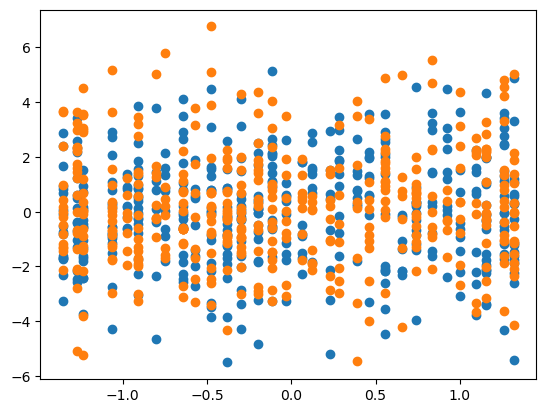

In [105]:
ra=230
dec=60
pmra=0
pmdec=0
parallax=0.05
phot_g_mean_mag=19

t,psi,plx, Lambda, error = gmo.predict_astrometry_single_source(ra=ra,dec=dec,
                                    pmra=pmra,pmdec=pmdec,
                                    parallax=parallax,
                                    data_release="dr3",
                                    phot_g_mean_mag=phot_g_mean_mag,
                                    c_funcs=None
                                   )
print("RUWE",gmo.check_ruwe(t_ast_yr=t, psi=psi, plx_factor=plx, ast_obs=Lambda, ast_err=error,binned=False)[0])
plt.scatter(t,Lambda)


varmodel=RRLVariable(datadf.iloc[20],fchrom=2,relative_norm=False)
t,psi,plx, Lambda, error = gmo.predict_astrometry_single_source(ra=ra,dec=dec,
                                    pmra=pmra,pmdec=pmdec,
                                    parallax=parallax,
                                    data_release="dr3",
                                    phot_g_mean_mag=phot_g_mean_mag,
                                    c_funcs=None,
                                    variability_tool=varmodel
                                   )
print("RUWE",gm.check_ruwe(t_ast_yr=t, psi=psi, plx_factor=plx, ast_obs=Lambda, ast_err=error,binned=False)[0])
plt.scatter(t,Lambda)

In [70]:
datadf.int_average_g

0      13.352346
1      13.549454
2      14.194406
3      12.924282
4      13.969219
         ...    
281    13.680594
282    15.473362
283    13.542380
284    13.067834
285    11.069887
Name: int_average_g, Length: 286, dtype: float64